In [ ]:
#EDA

In [14]:
import sys
from pathlib import Path

# Find and add src to path
for base in [Path.cwd(), Path.cwd().parent]:
    src = base / "src"
    if (src / "ucinsure").exists():
        sys.path.insert(0, str(src))
        print(f" Found ucinsure at: {src}")
        break
else:
    print("Could not find src/ucinsure - check your folder location")

 Found ucinsure at: D:\Asmita-Working_Directory\UCI (coursework)\Courses\Final-Year-Project\git-UCInsure-project\UCInsure\src


In [15]:
from importlib import reload
import ucinsure.data_loader as dl
import ucinsure.use_cases.uc03_preprocess as uc03
reload(dl)
reload(uc03)

from ucinsure.data_loader import load_claims_data
from ucinsure.use_cases.uc03_preprocess import preprocess_dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

raw = load_claims_data(nrows=50_000)
df = preprocess_dataset(raw)
print("Ready! Shape:", df.shape)

Ready! Shape: (49484, 15)


In [17]:
df.dtypes

dateOfLoss                             object
numberOfFloorsInTheInsuredBuilding    float64
occupancyType                         float64
amountPaidOnBuildingClaim             float64
amountPaidOnContentsClaim             float64
yearOfLoss                              int64
primaryResidenceIndicator               int64
buildingDamageAmount                  float64
buildingPropertyValue                 float64
floodEvent                             object
waterDepth                            float64
reportedCity                           object
reportedZipCode                       float64
latitude                              float64
longitude                             float64
dtype: object

In [18]:
df.head()

,dateOfLoss,numberOfFloorsInTheInsuredBuilding,occupancyType,amountPaidOnBuildingClaim,amountPaidOnContentsClaim,yearOfLoss,primaryResidenceIndicator,buildingDamageAmount,buildingPropertyValue,floodEvent,waterDepth,reportedCity,reportedZipCode,latitude,longitude
0,1991-10-08T00:00:00.000Z,3.0,3.0,10000.00,0.00,1991,0,11582.0,111476.5,Flooding,0.0,Currently Unavailable,33004.0,26.1,-80.1
1,2017-07-28T00:00:00.000Z,2.0,11.0,12123.35,0.00,2017,1,14123.0,86298.0,Flooding,6.0,Currently Unavailable,26040.0,40.0,-80.7
2,1984-05-07T00:00:00.000Z,1.0,2.0,5731.50,2057.46,1984,0,6250.0,69000.0,Flooding,1.0,Currently Unavailable,40997.0,36.9,-83.7
3,1996-09-05T00:00:00.000Z,2.0,1.0,18072.46,12684.50,1996,1,19875.0,19875.0,Hurricane Fran,72.0,Currently Unavailable,28409.0,34.1,-77.9
4,2012-03-30T00:00:00.000Z,1.0,11.0,41144.46,2277.89,2012,1,38601.0,117144.0,Flooding,14.0,Currently Unavailable,78501.0,26.2,-98.2


In [ ]:
#Payment Distributions

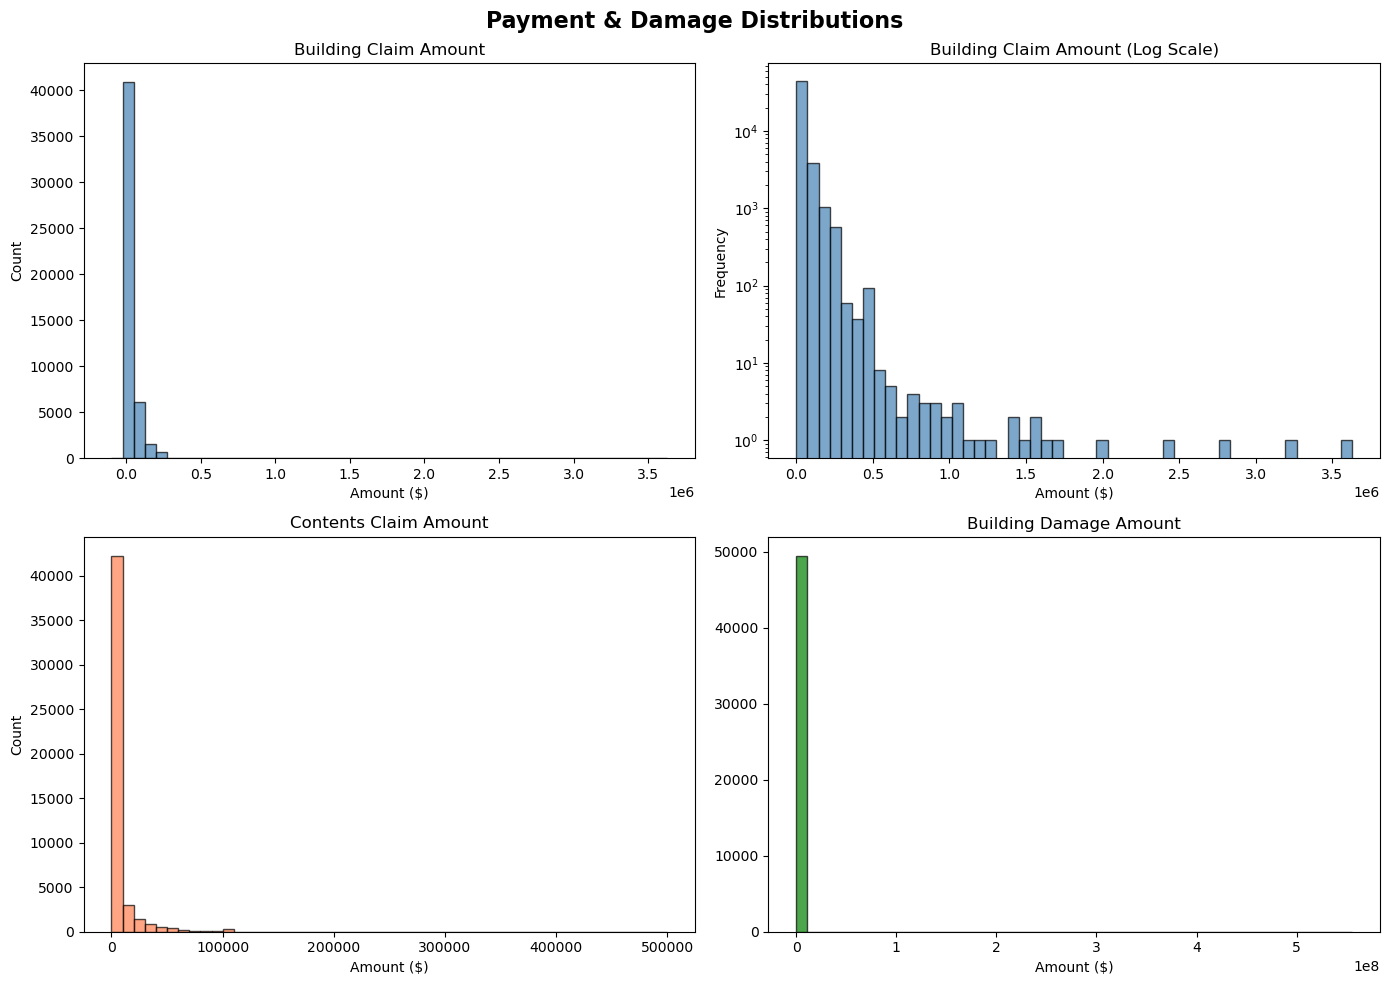

Payment distributions plotted


In [19]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Payment & Damage Distributions", fontsize=16, fontweight="bold")

# Building claim
axes[0,0].hist(df["amountPaidOnBuildingClaim"], bins=50, color="steelblue", edgecolor="black", alpha=0.7)
axes[0,0].set_title("Building Claim Amount")
axes[0,0].set_xlabel("Amount ($)")
axes[0,0].set_ylabel("Count")

# Building claim log scale
df["amountPaidOnBuildingClaim"].clip(lower=1).plot(kind="hist", bins=50, ax=axes[0,1], color="steelblue", edgecolor="black", alpha=0.7)
axes[0,1].set_yscale("log")
axes[0,1].set_title("Building Claim Amount (Log Scale)")
axes[0,1].set_xlabel("Amount ($)")

# Contents claim
axes[1,0].hist(df["amountPaidOnContentsClaim"], bins=50, color="coral", edgecolor="black", alpha=0.7)
axes[1,0].set_title("Contents Claim Amount")
axes[1,0].set_xlabel("Amount ($)")
axes[1,0].set_ylabel("Count")

# Building damage
axes[1,1].hist(df["buildingDamageAmount"], bins=50, color="green", edgecolor="black", alpha=0.7)
axes[1,1].set_title("Building Damage Amount")
axes[1,1].set_xlabel("Amount ($)")

plt.tight_layout()
plt.show()
print("Payment distributions plotted")

In [ ]:
#Risk Label Distribution

Quantile thresholds → Low: <$10,000 | Medium: <$19,528 | High: >$19,528


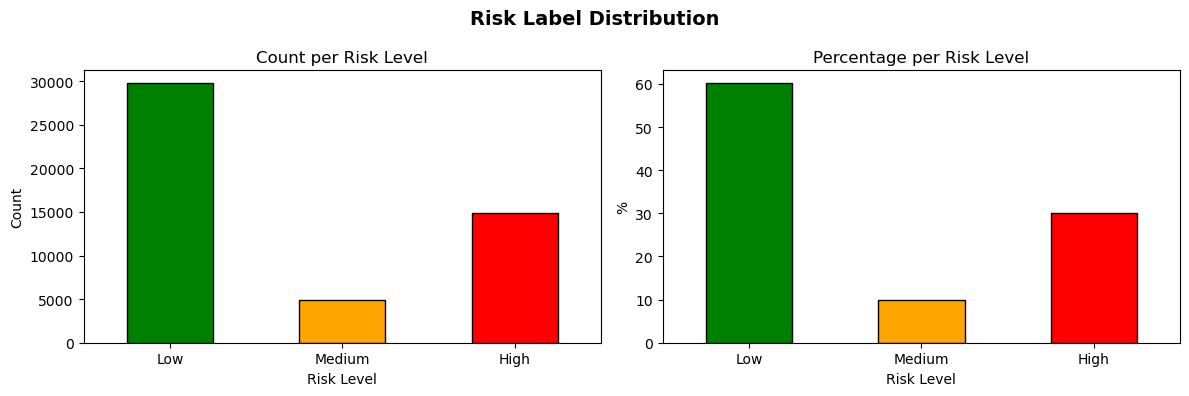

riskLabel
Low       29761
High      14845
Medium     4878
Name: count, dtype: int64


In [20]:
# Create risk labels same way as pipeline
q = df["amountPaidOnBuildingClaim"].quantile([0.4, 0.7]).values
print(f"Quantile thresholds → Low: <${q[0]:,.0f} | Medium: <${q[1]:,.0f} | High: >${q[1]:,.0f}")

df["riskLabel"] = pd.cut(
    df["amountPaidOnBuildingClaim"],
    bins=[-np.inf, q[0], q[1], np.inf],
    labels=["Low", "Medium", "High"]
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Risk Label Distribution", fontsize=14, fontweight="bold")

# Count
df["riskLabel"].value_counts().sort_index().plot(kind="bar", ax=axes[0], color=["green","orange","red"], edgecolor="black")
axes[0].set_title("Count per Risk Level")
axes[0].set_xlabel("Risk Level")
axes[0].set_ylabel("Count")
axes[0].tick_params(rotation=0)

# Percentage
(df["riskLabel"].value_counts(normalize=True).sort_index() * 100).plot(kind="bar", ax=axes[1], color=["green","orange","red"], edgecolor="black")
axes[1].set_title("Percentage per Risk Level")
axes[1].set_xlabel("Risk Level")
axes[1].set_ylabel("%")
axes[1].tick_params(rotation=0)

plt.tight_layout()
plt.show()
print(df["riskLabel"].value_counts())

In [ ]:
#Claims by Year

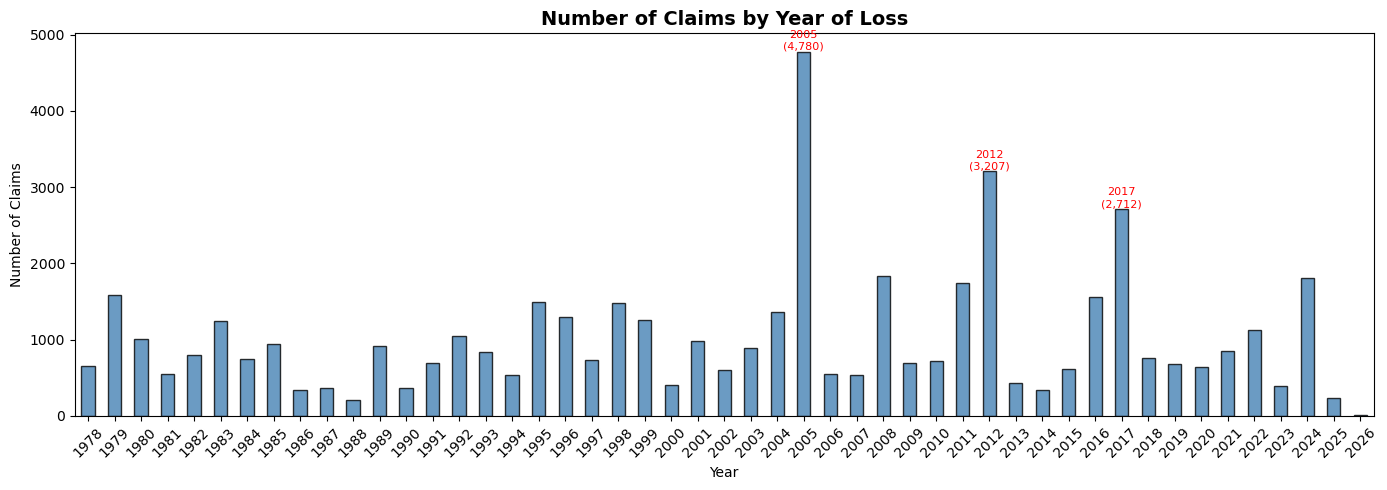


Top 5 years with most claims:
yearOfLoss
2005    4780
2012    3207
2017    2712
2008    1834
2024    1811
Name: count, dtype: int64


In [21]:
fig, ax = plt.subplots(figsize=(14, 5))
year_counts = df["yearOfLoss"].value_counts().sort_index()
year_counts.plot(kind="bar", ax=ax, color="steelblue", edgecolor="black", alpha=0.8)
ax.set_title("Number of Claims by Year of Loss", fontsize=14, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Number of Claims")
ax.tick_params(axis="x", rotation=45)

# Highlight top 3 years
top3 = year_counts.nlargest(3)
for year, count in top3.items():
    ax.annotate(f"{year}\n({count:,})", 
                xy=(list(year_counts.index).index(year), count),
                ha="center", va="bottom", fontsize=8, color="red")

plt.tight_layout()
plt.show()
print("\nTop 5 years with most claims:")
print(year_counts.nlargest(5))

In [ ]:
#Occupancy Type & Primary Residence

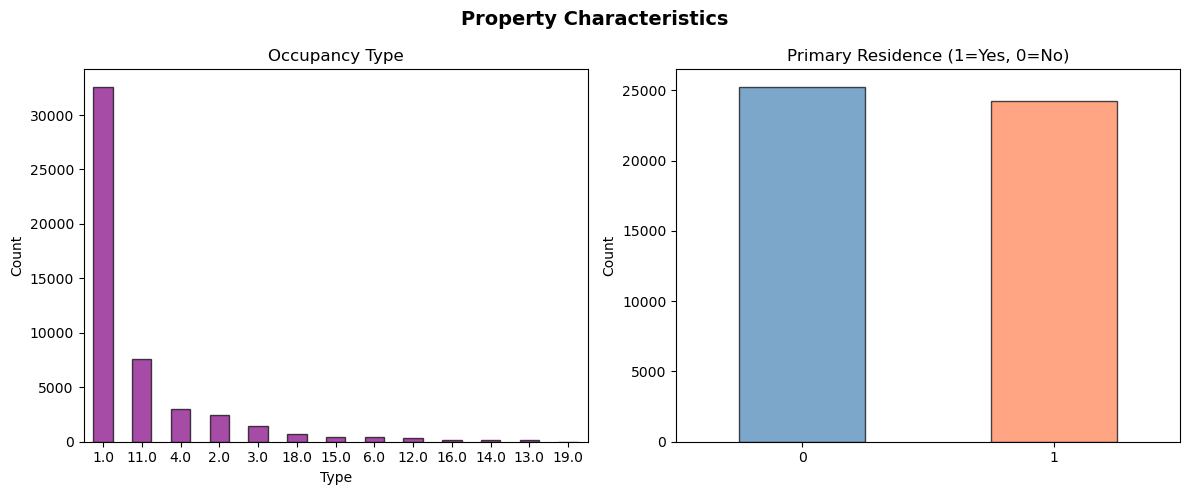

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Property Characteristics", fontsize=14, fontweight="bold")

# Occupancy type
df["occupancyType"].value_counts().plot(kind="bar", ax=axes[0], color="purple", edgecolor="black", alpha=0.7)
axes[0].set_title("Occupancy Type")
axes[0].set_xlabel("Type")
axes[0].set_ylabel("Count")
axes[0].tick_params(rotation=0)

# Primary residence
df["primaryResidenceIndicator"].value_counts().plot(kind="bar", ax=axes[1], color=["steelblue","coral"], edgecolor="black", alpha=0.7)
axes[1].set_title("Primary Residence (1=Yes, 0=No)")
axes[1].set_xlabel("")
axes[1].set_ylabel("Count")
axes[1].tick_params(rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
#Water Depth Analysis

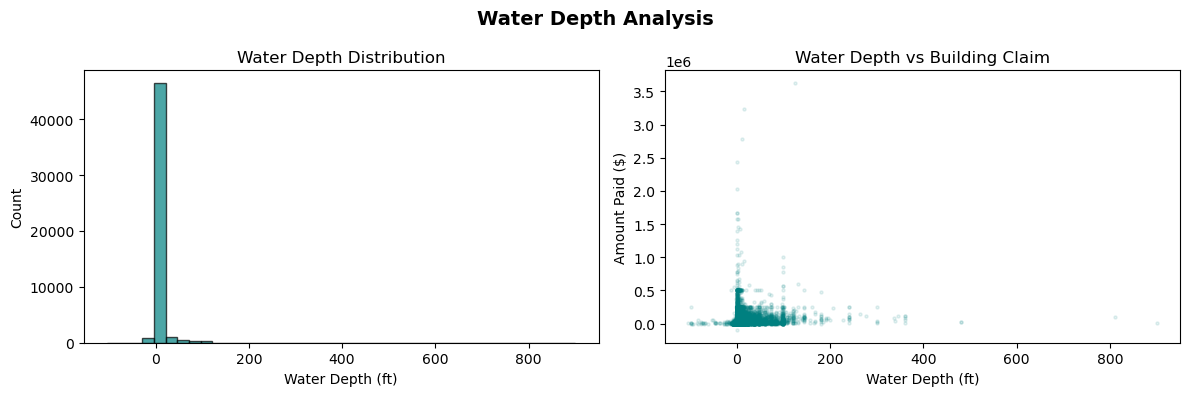


Water Depth Stats:
count    49484.00
mean         4.13
std         16.34
min       -104.00
25%          0.00
50%          1.00
75%          2.00
max        900.00
Name: waterDepth, dtype: float64


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Water Depth Analysis", fontsize=14, fontweight="bold")

# Distribution
axes[0].hist(df["waterDepth"], bins=40, color="teal", edgecolor="black", alpha=0.7)
axes[0].set_title("Water Depth Distribution")
axes[0].set_xlabel("Water Depth (ft)")
axes[0].set_ylabel("Count")

# Water depth vs building claim
axes[1].scatter(df["waterDepth"], df["amountPaidOnBuildingClaim"], alpha=0.1, color="teal", s=5)
axes[1].set_title("Water Depth vs Building Claim")
axes[1].set_xlabel("Water Depth (ft)")
axes[1].set_ylabel("Amount Paid ($)")

plt.tight_layout()
plt.show()

print("\nWater Depth Stats:")
print(df["waterDepth"].describe().round(2))

In [ ]:
#Top Cities by Claims

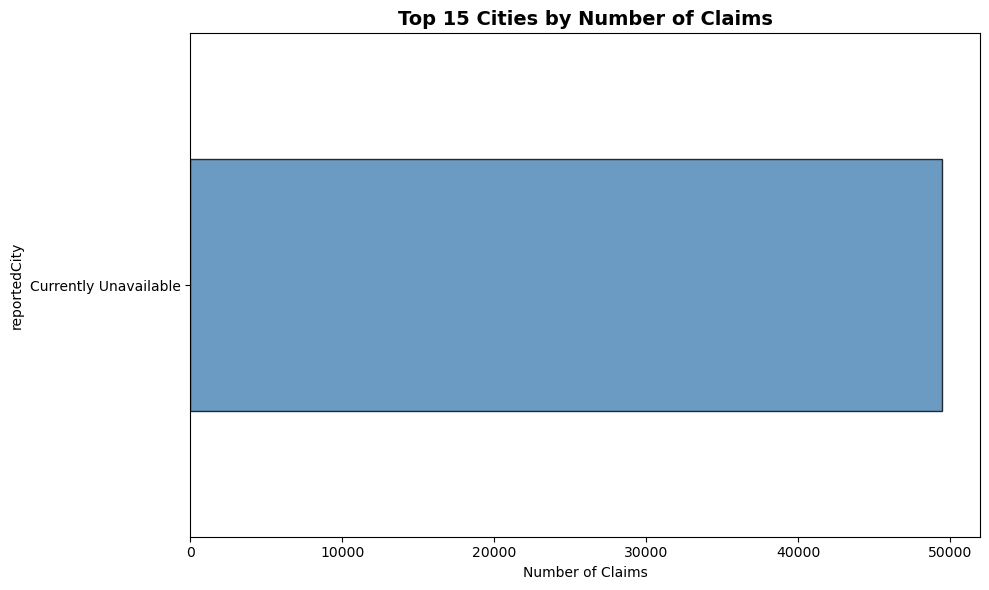


Top 10 cities:
reportedCity
Currently Unavailable    49484
Name: count, dtype: int64


In [9]:
fig, ax = plt.subplots(figsize=(10, 6))
top_cities = df["reportedCity"].value_counts().head(15)
top_cities.plot(kind="barh", ax=ax, color="steelblue", edgecolor="black", alpha=0.8)
ax.set_title("Top 15 Cities by Number of Claims", fontsize=14, fontweight="bold")
ax.set_xlabel("Number of Claims")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 10 cities:")
print(top_cities.head(10))

In [ ]:
#Correlation Heatmap

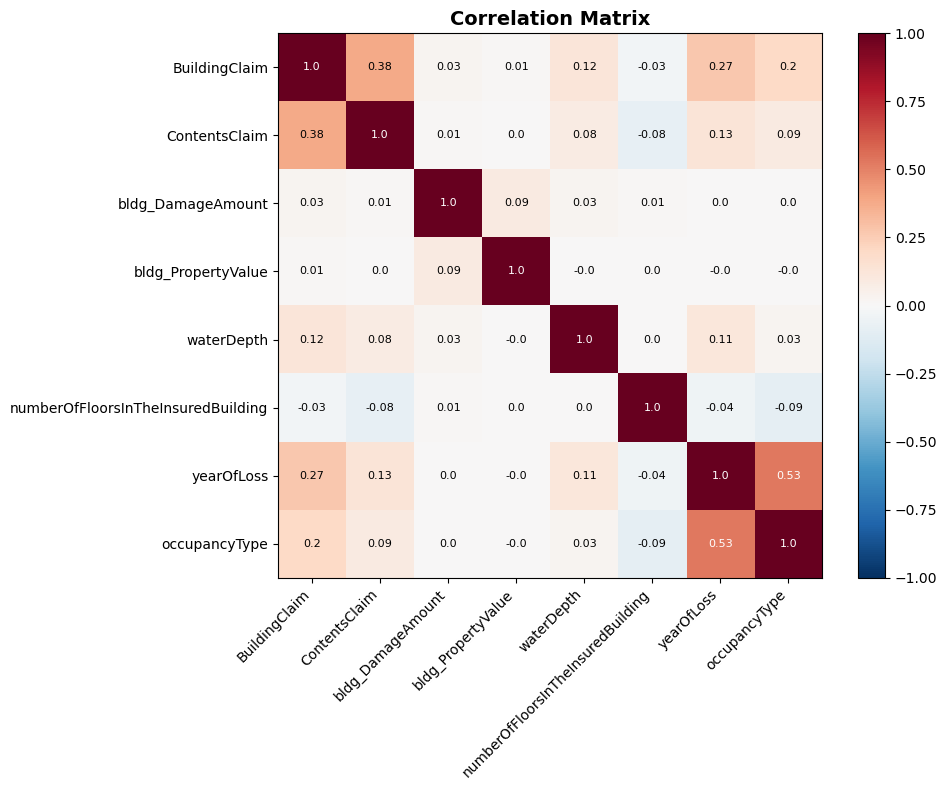


Strongest correlations with Building Claim:
amountPaidOnBuildingClaim             1.00
amountPaidOnContentsClaim             0.38
yearOfLoss                            0.27
occupancyType                         0.20
waterDepth                            0.12
buildingDamageAmount                  0.03
buildingPropertyValue                 0.01
numberOfFloorsInTheInsuredBuilding   -0.03
Name: amountPaidOnBuildingClaim, dtype: float64


In [10]:
numeric_cols = ["amountPaidOnBuildingClaim", "amountPaidOnContentsClaim", 
                "buildingDamageAmount", "buildingPropertyValue",
                "waterDepth", "numberOfFloorsInTheInsuredBuilding",
                "yearOfLoss", "occupancyType"]

corr = df[numeric_cols].corr().round(2)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)

ax.set_xticks(range(len(numeric_cols)))
ax.set_xticklabels([c.replace("amountPaidOn","").replace("building","bldg_") for c in numeric_cols], rotation=45, ha="right")
ax.set_yticks(range(len(numeric_cols)))
ax.set_yticklabels([c.replace("amountPaidOn","").replace("building","bldg_") for c in numeric_cols])

# Add correlation values
for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        ax.text(j, i, str(corr.iloc[i, j]), ha="center", va="center", fontsize=8,
                color="white" if abs(corr.iloc[i, j]) > 0.5 else "black")

ax.set_title("Correlation Matrix", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("\nStrongest correlations with Building Claim:")
print(corr["amountPaidOnBuildingClaim"].sort_values(ascending=False))

In [ ]:
#Risk Level vs Key Features

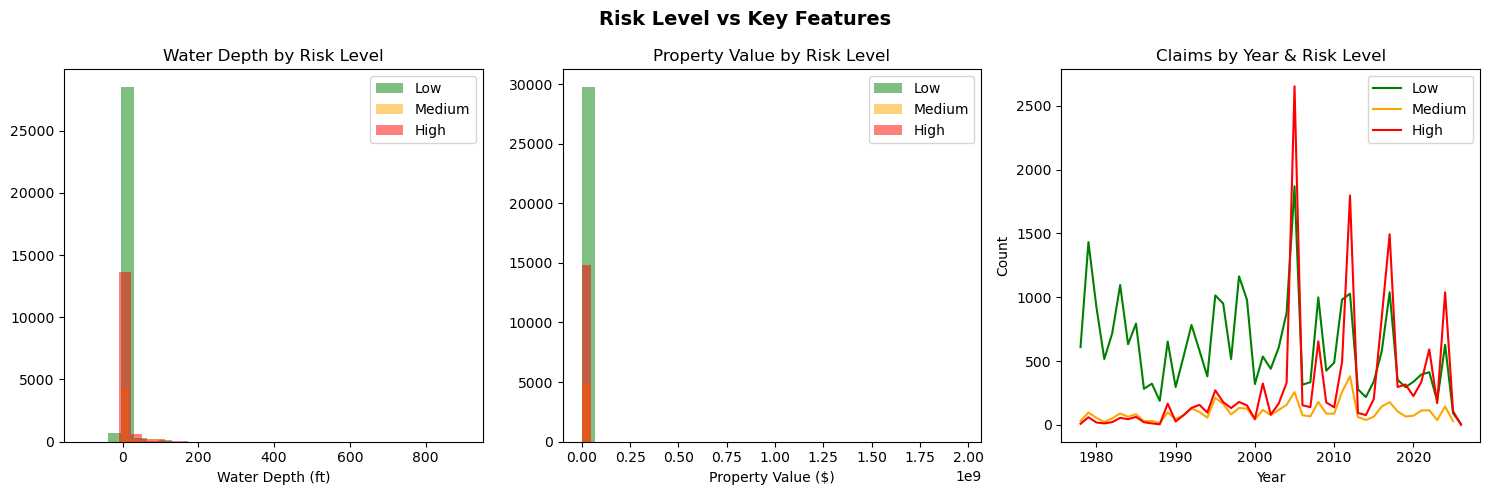

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Risk Level vs Key Features", fontsize=14, fontweight="bold")

colors = {"Low": "green", "Medium": "orange", "High": "red"}

# Water depth by risk
for risk in ["Low", "Medium", "High"]:
    data = df[df["riskLabel"] == risk]["waterDepth"]
    axes[0].hist(data, bins=30, alpha=0.5, label=risk, color=colors[risk])
axes[0].set_title("Water Depth by Risk Level")
axes[0].set_xlabel("Water Depth (ft)")
axes[0].legend()

# Property value by risk
for risk in ["Low", "Medium", "High"]:
    data = df[df["riskLabel"] == risk]["buildingPropertyValue"]
    axes[1].hist(data, bins=30, alpha=0.5, label=risk, color=colors[risk])
axes[1].set_title("Property Value by Risk Level")
axes[1].set_xlabel("Property Value ($)")
axes[1].legend()

# Claims by year and risk
for risk in ["Low", "Medium", "High"]:
    year_risk = df[df["riskLabel"] == risk]["yearOfLoss"].value_counts().sort_index()
    axes[2].plot(year_risk.index, year_risk.values, label=risk, color=colors[risk])
axes[2].set_title("Claims by Year & Risk Level")
axes[2].set_xlabel("Year")
axes[2].set_ylabel("Count")
axes[2].legend()

plt.tight_layout()
plt.show()

In [13]:
print("="*55)
print("EDA INSIGHTS SUMMARY")
print("="*55)

print(f"\n DATASET")
print(f"   Total claims analysed : {len(df):,}")
print(f"   Years covered         : {df['yearOfLoss'].min()} - {df['yearOfLoss'].max()}")
print(f"   Top city              : {df['reportedCity'].value_counts().index[0]}")

print(f"\n PAYMENTS")
print(f"   Avg building claim    : ${df['amountPaidOnBuildingClaim'].mean():,.0f}")
print(f"   Max building claim    : ${df['amountPaidOnBuildingClaim'].max():,.0f}")
print(f"   Avg contents claim    : ${df['amountPaidOnContentsClaim'].mean():,.0f}")

print(f"\n WATER DEPTH")
print(f"   Average depth         : {df['waterDepth'].mean():.1f} ft")
print(f"   Max depth             : {df['waterDepth'].max():.1f} ft")

print(f"\n RISK LABELS")
for risk in ["Low", "Medium", "High"]:
    count = (df["riskLabel"] == risk).sum()
    pct = count / len(df) * 100
    print(f"   {risk:6} : {count:,} ({pct:.1f}%)")

print(f"\n STRONGEST CORRELATIONS WITH BUILDING CLAIM")
corr_vals = df[["amountPaidOnBuildingClaim","buildingDamageAmount",
                "waterDepth","buildingPropertyValue"]].corr()["amountPaidOnBuildingClaim"]
for col, val in corr_vals.drop("amountPaidOnBuildingClaim").sort_values(ascending=False).items():
    print(f"   {col:35}: {val:.3f}")

EDA INSIGHTS SUMMARY

 DATASET
   Total claims analysed : 49,484
   Years covered         : 1978 - 2026
   Top city              : Currently Unavailable

 PAYMENTS
   Avg building claim    : $28,948
   Max building claim    : $3,630,000
   Avg contents claim    : $5,768

 WATER DEPTH
   Average depth         : 4.1 ft
   Max depth             : 900.0 ft

 RISK LABELS
   Low    : 29,761 (60.1%)
   Medium : 4,878 (9.9%)
   High   : 14,845 (30.0%)

 STRONGEST CORRELATIONS WITH BUILDING CLAIM
   waterDepth                         : 0.123
   buildingDamageAmount               : 0.029
   buildingPropertyValue              : 0.015
